In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv")

df.columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
cols = ['Glucose','BloodPressure','BMI','Insulin']

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values using mean
imputer = SimpleImputer(strategy='mean')
df[cols] = imputer.fit_transform(df[cols])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85.0,66.0,29,155.548223,26.6,0.351,31,0
1,8,183.0,64.0,0,155.548223,23.3,0.672,32,1
2,1,89.0,66.0,23,94.000000,28.1,0.167,21,0
3,0,137.0,40.0,35,168.000000,43.1,2.288,33,1
4,5,116.0,74.0,0,155.548223,25.6,0.201,30,0


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(X.head())
print(y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            1     85.0           66.0             29  155.548223  26.6   
1            8    183.0           64.0              0  155.548223  23.3   
2            1     89.0           66.0             23   94.000000  28.1   
3            0    137.0           40.0             35  168.000000  43.1   
4            5    116.0           74.0              0  155.548223  25.6   

   DiabetesPedigreeFunction  Age  
0                     0.351   31  
1                     0.672   32  
2                     0.167   21  
3                     2.288   33  
4                     0.201   30  
0    0
1    1
2    0
3    1
4    0
Name: Outcome, dtype: int64


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.792208   0.755102  0.649123  0.698113
1        Decision Tree  0.636364   0.509091  0.491228  0.500000
2        Random Forest  0.831169   0.771930  0.771930  0.771930
3                  SVM  0.792208   0.755102  0.649123  0.698113
4                  KNN  0.753247   0.661017  0.684211  0.672414


In [ ]:
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
import numpy as np

# Example input (you can change values)
input_data = np.array([[6,148,72,35,0,33.6,0.627,50]])

# Apply scaling (VERY IMPORTANT)
input_scaled = scaler.transform(input_data)

# Prediction
prediction = final_model.predict(input_scaled)

# Output
if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Not Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np

# Take input from user
preg = int(input("Enter Pregnancies: "))
glu = int(input("Enter Glucose: "))
bp = int(input("Enter Blood Pressure: "))
skin = int(input("Enter Skin Thickness: "))
ins = int(input("Enter Insulin: "))
bmi = float(input("Enter BMI: "))
dpf = float(input("Enter Diabetes Pedigree Function: "))
age = int(input("Enter Age: "))

# Convert into array
user_input = pd.DataFrame([[preg, glu, bp, skin, ins, bmi, dpf, age]],
                          columns=X.columns)

# Apply scaling
user_scaled = scaler.transform(user_input)

# Predict
result = final_model.predict(user_scaled)

# Output
if result[0] == 1:
    print("Result: Diabetic")
else:
    print("Result: Not Diabetic")

Enter Pregnancies: 0
Enter Glucose: 170
Enter Blood Pressure: 80
Enter Skin Thickness: 35
Enter Insulin: 150
Enter BMI: 32.5
Enter Diabetes Pedigree Function: 0.8
Enter Age: 45
Result: Diabetic


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann = Sequential()

ann.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dropout(0.3))  # Optimization
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = ann.fit(X_train, y_train, epochs=50, batch_size=10, verbose=1)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3899 - loss: 0.8174
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6232 - loss: 0.6774
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6933 - loss: 0.6290
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7292 - loss: 0.5748
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7210 - loss: 0.5468
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7227 - loss: 0.5242
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7537 - loss: 0.4972
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7504 - loss: 0.5044
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7520 - loss: 0.5013
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7716 - loss: 0.4946
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7586 - loss: 0.4885
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7471 - lo

In [ ]:
ann_pred = (ann.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [ ]:
print("ANN Accuracy:", accuracy_score(y_test, ann_pred))
print("Precision:", precision_score(y_test, ann_pred))
print("Recall:", recall_score(y_test, ann_pred))
print("F1 Score:", f1_score(y_test, ann_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, ann_pred))

ANN Accuracy: 0.7792207792207793
Precision: 0.7090909090909091
Recall: 0.6842105263157895
F1 Score: 0.6964285714285714

Confusion Matrix:
 [[81 16]
 [18 39]]


In [ ]:
# Add ANN results to your existing dataframe
ann_results = pd.DataFrame([[
    "ANN",
    accuracy_score(y_test, ann_pred),
    precision_score(y_test, ann_pred),
    recall_score(y_test, ann_pred),
    f1_score(y_test, ann_pred)
]], columns=["Model","Accuracy","Precision","Recall","F1"])

final_results = pd.concat([results_df, ann_results], ignore_index=True)

# Sort by Accuracy
final_results = final_results.sort_values(by="Accuracy", ascending=False)

print(final_results)

                 Model  Accuracy  Precision    Recall        F1
2        Random Forest  0.831169   0.771930  0.771930  0.771930
0  Logistic Regression  0.792208   0.755102  0.649123  0.698113
3                  SVM  0.792208   0.755102  0.649123  0.698113
5                  ANN  0.779221   0.709091  0.684211  0.696429
4                  KNN  0.753247   0.661017  0.684211  0.672414
1        Decision Tree  0.636364   0.509091  0.491228  0.500000


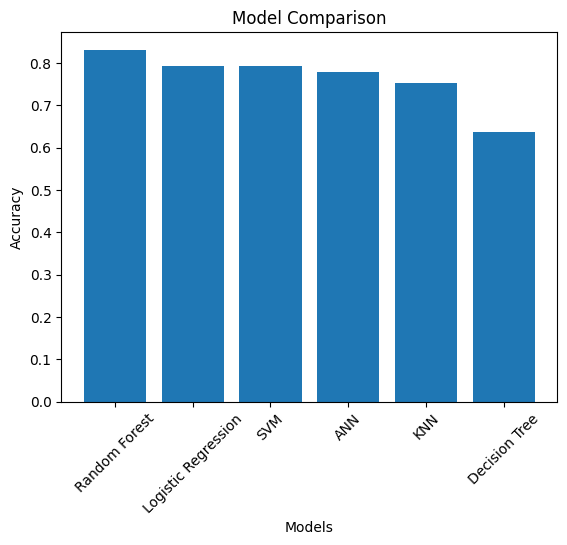

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(final_results["Model"], final_results["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()